# 05 — Recommandation (Content-Based)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

BASE       = Path('d:/Smart-Free_GestionMess+Feedback/Smart-Free_GestionMess/ml-service')
MODELS_DIR = BASE / 'models'
MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(BASE / 'data' / 'clean.csv')
print('Shape :', df.shape)

Shape : (8871, 14)


In [2]:
df['corpus'] = (df['job_title'].fillna('') + ' ' + df['tags_clean'].fillna('')).str.lower()

tfidf_rec = TfidfVectorizer(max_features=200, ngram_range=(1,2), stop_words='english')
project_matrix = tfidf_rec.fit_transform(df['corpus'])
print('Matrice projets :', project_matrix.shape)

Matrice projets : (8871, 200)


In [3]:
def recommend(category, target_budget, top_n=5, sim_w=0.6, budget_w=0.4):
    query = tfidf_rec.transform([category.lower()])
    sim   = cosine_similarity(query, project_matrix).flatten()
    bdiff = np.abs(df['avg_price'] - target_budget)
    bscore = 1 - bdiff / (bdiff.max() or 1)
    score  = sim_w * sim + budget_w * bscore.values
    idx    = np.argsort(score)[::-1][:top_n]
    res    = df.iloc[idx][['projectId','job_title','tags_clean','avg_price','rate_type','client_country']].copy()
    res['score'] = score[idx].round(4)
    return res.reset_index(drop=True)

In [4]:
print('=== Web Developer — 500$ ===')
display(recommend('web development javascript react', 500))

=== Web Developer — 500$ ===


,projectId,job_title,tags_clean,avg_price,rate_type,client_country,score
0,34648329,Web development for geospatial analysis -- 3,"php,javascript,python,cartography & maps,geosp...",1125.0,fixed,India,0.8966
1,36638335,Puzzle Game -- 3,"game development,javascript,html5,python,css",1050.0,fixed,India,0.8914
2,36332383,Langchain Web Frontend - Chatbot,"python,javascript,chatgpt",140.0,fixed,Australia,0.8482
3,31622945,Fit4fuN dashboard,"backend development,frontend development,web d...",24.0,fixed,Italy,0.7818
4,36594674,"Building a SaaS Application (UI, Front-End, Ba...","full stack development,web development,saas,py...",1125.0,fixed,United Arab Emirates,0.7660


In [5]:
print('=== Data Scientist — 2000$ ===')
display(recommend('data science machine learning python', 2000))

=== Data Scientist — 2000$ ===


,projectId,job_title,tags_clean,avg_price,rate_type,client_country,score
0,33066798,Data Science based on employee history,"python,keras,data science,machine learning (ml)",20.0,fixed,United States,0.8955
1,32289633,Mortage Insurance cross sell Case study,"data science,python,machine learning (ml)",1050.0,fixed,India,0.8777
2,37179060,"Programmer needed with Python, Data Science, M...","python,machine learning (ml),data science,algo...",575.0,hourly,India,0.8776
3,31238968,Data Science,"python,machine learning (ml)",140.0,fixed,Italy,0.8744
4,36995332,Data Science Project - Machine Learning on Hea...,"machine learning (ml),data science,data visual...",140.0,fixed,Turkey,0.8562


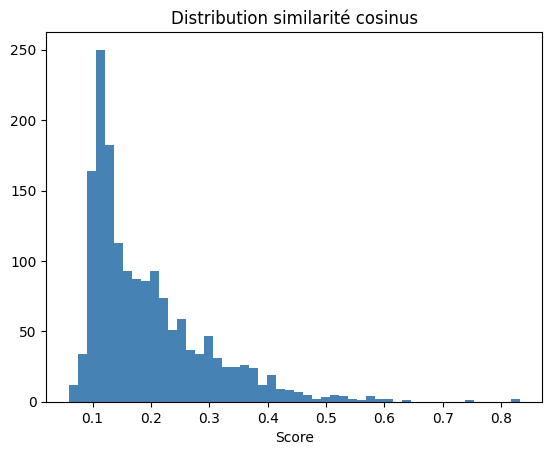

In [6]:
query = tfidf_rec.transform(['web development javascript'])
sim   = cosine_similarity(query, project_matrix).flatten()
plt.hist(sim[sim > 0], bins=50, color='steelblue')
plt.title('Distribution similarité cosinus'); plt.xlabel('Score'); plt.show()

In [7]:
joblib.dump(tfidf_rec,      MODELS_DIR / 'tfidf_rec.pkl')
joblib.dump(project_matrix, MODELS_DIR / 'project_matrix.pkl')
print('Sauvegardés → models/tfidf_rec.pkl  models/project_matrix.pkl')

Sauvegardés → models/tfidf_rec.pkl  models/project_matrix.pkl
